# Comparison of Empirical Results to Mathematical Analysis

### Setup

In [388]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as clr
import matplotlib 
import numpy as np
import random
import math
import networkx as nx
import itertools

from msean import load_config, save_config
from msean.analysis.mc_integration import gen_expected_weighting_lookup, q, find_closest_coords, p_delta, normalise_as_pdf, sq_line_picking_prob
from msean.analysis.mc_integration import sq_line_picking_prob
from msean.generation import gen

Load configuration from file <b>configs/default.yaml</b>.

In [385]:
# Load configuration file
root = Path.cwd().parents[0] # go up from notebooks/ to project root
cfg = load_config(root / "configs" / "default.yaml")
runs_dir = root / "runs"

In [386]:
rng = np.random.default_rng(cfg.seed)

### Connection Function

$\omega(d(\mathbf x_u, \mathbf x_{a^\ell_i})) = \exp\left({- \frac{d(\mathbf x_u, \mathbf x_{a^\ell_i})}{\alpha \sqrt{2}}}\right)$ 

As $\alpha$ increases, spatial strength decreases and the probability of connection becomes flatter across scales.

In [4]:
alphas = [0.01 * 2**i for i in range(1, 13)]

deltas = np.linspace(0, math.sqrt(2),101)[:-1]
connection_fs = []

for alpha in alphas:
    connection_fs.append([math.exp(-delta/(math.sqrt(2)*alpha)) for delta in deltas])

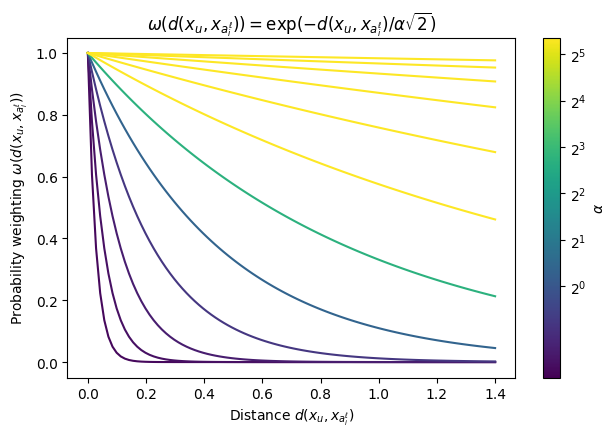

In [5]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_axes([0.10,0.10,0.70,0.85])

colormap = plt.cm.viridis

for alpha, probs in zip(alphas, connection_fs):
    plt.plot(deltas, probs, color=colormap(alpha))

sm = plt.cm.ScalarMappable(cmap = colormap, norm=clr.SymLogNorm(1, vmin=alphas[0], vmax=alphas[-1], base=2))
plt.colorbar(sm, ax=ax, label='$\\alpha$')

plt.xlabel('Distance $d(x_u, x_{a^\\ell_i})$')
plt.ylabel('Probability weighting $\\omega(d(x_u, x_{a^\\ell_i}))$')

plt.title('$\\omega(d(x_u, x_{a^\\ell_i})) = \\exp(-{d(x_u, x_{a^\\ell_i})} / {\\alpha \\sqrt{2}})$')
plt.show()

### Expected Weighting for Nodes

$\overline \omega (\mathbf x_u) 
= \int_0^1 \omega (d (\mathbf x_u, \mathbf x_{a^\ell_i})) 
\cdot f_{\mathbf X_{\mathcal A}}(\mathbf x_{a^\ell_i}) 
~ \text{d}\mathbf x_{a^\ell_i}$

Generate a lookup table for the expected weighting of a node at each position.

In [9]:
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)

In [16]:
from msean.analysis.mc_integration import write_lookup_to_file, read_lookup_from_file

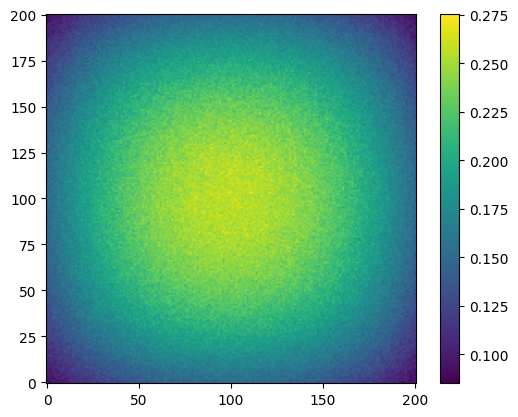

In [10]:
fig, ax = plt.subplots()
im = ax.imshow(weighting_lkup)
fig.colorbar(im)
ax.invert_yaxis()
plt.show()

### Connection Probabilities

$q(\mathbf x_v, \mathbf x_u)$ is the probability that two nodes at positions $\mathbf x_v$ and $\mathbf x_u$ connect.

Probability of connection between two randomly placed nodes.

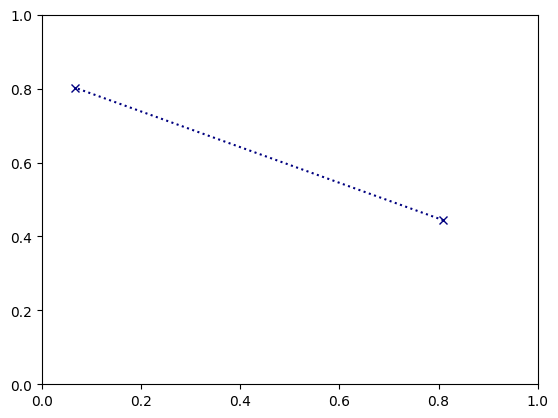

q((0.8100, 0.4437), (0.0677, 0.8022)) = 5.618601713463702e-05


In [11]:
x_u, y_u = (random.uniform(0, 1), random.uniform(0,1))
x_v, y_v = (random.uniform(0, 1), random.uniform(0,1))

plt.plot([x_u, x_v], [y_u, y_v], c='navy', marker='x', ls=':')
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

q_uv = q(cfg, x_u, y_u, x_v, y_v, weighting_coords, weighting_lkup, 100)
print(f'q(({x_u:.4f}, {y_u:.4f}), ({x_v:.4f}, {y_v:.4f})) = {q_uv}')

Probability of connection from one node to every other position.

In [12]:
x_u, y_u = (random.uniform(0, 1), random.uniform(0,1))
res = 101
K = 100

q_coords = np.linspace(0, 1, res)
q_vals = np.zeros((res, res))

for i, x_v in enumerate(q_coords):
    for j, y_v in enumerate(q_coords):
        q_vals[j][i] = q(cfg, x_u, y_u, x_v, y_v, weighting_coords, weighting_lkup, K)

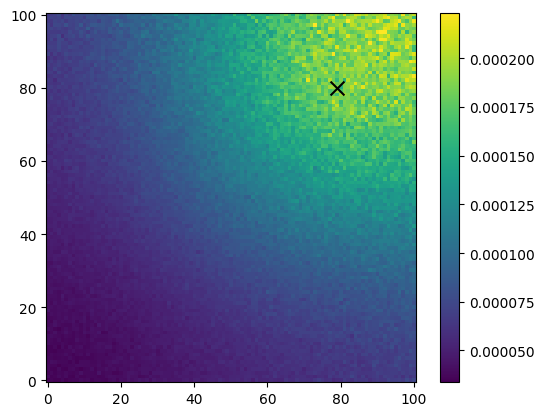

In [13]:
i_x, i_y = find_closest_coords(cfg, q_coords, x_u, y_u)

fig, ax = plt.subplots()
im = ax.imshow(q_vals)
fig.colorbar(im)
ax.scatter([i_x], [i_y], marker="x", color="black", s=100)
ax.invert_yaxis()

plt.show()

### Distance-Based Pairwise Connection

In [14]:
deltas = np.linspace(0,1,51)
p_deltas = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]


Text(0, 0.5, '$q_{\\delta}$')

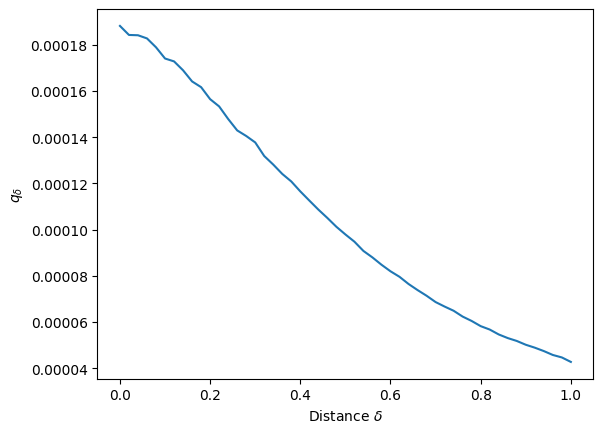

In [33]:
plt.plot(deltas, p_deltas)
plt.xlabel('Distance $\\delta$')
plt.ylabel('$q_{\\delta}$')

The Effect of $r_0$ on the Probability of Nodes Connecting

In [387]:
original_n_trials = cfg.analysis.mc.n_trials
cfg.analysis.mc.n_trials = 100

original_r_0 = cfg.connection.r_0
r_0s = [i*0.05 for i in range(1,21)] 

deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_delta_arrs = []

for r_0 in r_0s:
    cfg.connection.r_0 = r_0
    p_deltas = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
    p_delta_arrs.append(p_deltas)

cfg.connection.r_0 = original_r_0 #Reset r_0
cfg.analysis.mc.n_trials = original_n_trials #Reset n_trials

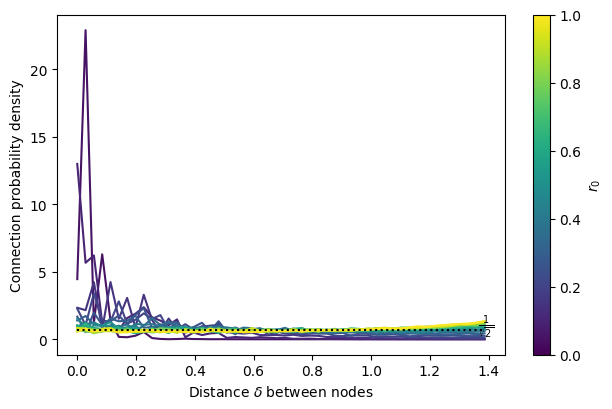

In [ ]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_axes([0.10,0.10,0.70,0.85])

colormap = plt.cm.viridis

step = deltas[1] - deltas[0]

for r_0, probs in zip(r_0s, p_delta_arrs):
    normalised_probs = normalise_as_pdf(probs, step)
    plt.plot(deltas, normalised_probs, label=f'$r_0 = ${r_0:.2f}', color=colormap(r_0))

sm = plt.cm.ScalarMappable(cmap = colormap)
sm.set_array([])
plt.plot(deltas, [1/math.sqrt(2) for _ in deltas], ls=':', color='black')
plt.colorbar(sm, ax=ax, label='$r_0$')

plt.xlabel('Distance $\\delta$ between nodes')
plt.ylabel('Connection probability density')
plt.annotate('$\\frac{1}{\\sqrt{2}}$', (1.362, 1/math.sqrt(2)))

plt.show()

<i> Why does it go up at the end? It didn't do that before

### Network Density

Network density increases as $r_0 \to 0$.

In [99]:
r_0s = [0.005, 0.01, 0.015, 0.02] + [0.025 * i for i in range(1,41)]

Empirical results:

<i> Replace this code with the batch code

In [ ]:
original_n_trials = cfg.analysis.mc.n_trials
original_r_0 = cfg.connection.r_0
original_L = cfg.network.n_layers 

cfg.network.n_layers = 1
cfg.analysis.mc.n_trials = 1000

empirical_rhos = []

for r_0 in r_0s:
    total = 0
    cfg.connection.r_0 = r_0
    for _ in range(cfg.analysis.mc.n_trials):
        G, layers = gen(cfg, rng)
        total += nx.density(G)
    empirical_rhos.append(total / cfg.analysis.mc.n_trials)

cfg.connection.r_0 = original_r_0 #Reset r_0
cfg.network.n_layers = original_L
cfg.analysis.mc.n_trials = original_n_trials

or read in from example file.

In [399]:
r_0s, empirical_rhos = read_lookup_from_file("empirical_density_r025_extra.csv")
r_0s = [float(r_0) for r_0 in r_0s]
empirical_rhos = [float(rho) for rho in empirical_rhos]

Plot the empirical results.

In [253]:
original_r_0 = cfg.connection.r_0
original_L = cfg.network.n_layers 
original_N = cfg.network.n_nodes
original_K = cfg.network.n_affiliations

cfg.network.n_layers = 1
cfg.network.n_nodes = 100
cfg.network.n_affiliations = [10]

cfg.connection.r_0 = 0.001
voronoi_G, layers = gen(cfg, rng)

cfg.connection.r_0 = 0.05
mixed_G, layers = gen(cfg, rng)

cfg.connection.r_0 = 1
er_G, layers = gen(cfg, rng)

cfg.connection.r_0 = original_r_0 #Reset r_0
cfg.network.n_layers = original_L
cfg.network.n_nodes = original_N
cfg.network.n_affiliations = original_K

c:\Users\hamil\OneDrive\Documents\Academic\Universiteit Leiden\msean\msean\.venv\Lib\site-packages\networkx\drawing\nx_pylab.py:1497: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  node_collection = ax.scatter(


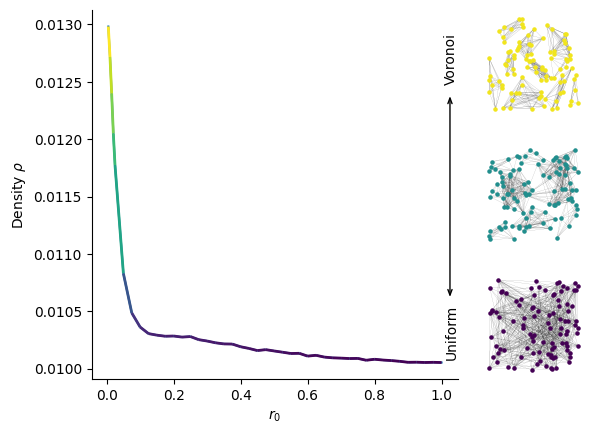

In [400]:
fig = plt.figure()
gs = plt.GridSpec(3, 4, figure=fig)
ax_rhos = fig.add_subplot(gs[:, :3])

ax_voronoi = fig.add_subplot(gs[0, 3])
ax_mixed = fig.add_subplot(gs[1, 3])
ax_er = fig.add_subplot(gs[2, 3])

ax_rhos.plot(r_0s, empirical_rhos) #, color='navy')
#ax_rhos.plot(r_0s, [1.28/cfg.network.n_affiliations[0] for r_0 in r_0s], color='crimson', ls=':')
#ax_rhos.plot(r_0s, [1/cfg.network.n_affiliations[0] for r_0 in r_0s], color='crimson', ls=':')
ax_rhos.set_xlabel('$r_0$')
ax_rhos.set_ylabel('Density $\\rho$')

ax_rhos.spines['top'].set_visible(False)
ax_rhos.spines['right'].set_visible(False)

points = np.array([r_0s, empirical_rhos]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a continuous norm to map from data points to colors
norm = plt.Normalize(min(empirical_rhos), max(empirical_rhos))
lc = matplotlib.collections.LineCollection(segments, cmap='viridis', norm=norm)
# Set the values used for colormapping
lc.set_array(empirical_rhos)
lc.set_linewidth(2)
line = ax_rhos.add_collection(lc)

#ax_rhos.set_yticks(np.append(ax_rhos.get_yticks(), 0.0128))

arrow = matplotlib.patches.FancyArrowPatch((1.025, 0.0106), (1.025, 0.0124), arrowstyle='<->,head_width=.15', mutation_scale=10)
ax_rhos.add_patch(arrow)
ax_rhos.annotate('Voronoi', (1.008, 0.0125), rotation=90)
ax_rhos.annotate('Uniform', (1.008, 0.0101), rotation=90)

nx.draw(voronoi_G, pos={v: voronoi_G.nodes[v]['embedding'] for v in voronoi_G}, node_color=plt.cm.viridis(250), node_size=5, width=0.05, ax=ax_voronoi)
nx.draw(mixed_G, pos={v: mixed_G.nodes[v]['embedding'] for v in mixed_G}, node_color=plt.cm.viridis(125), node_size=5, width=0.05, ax=ax_mixed)
nx.draw(er_G, pos={v: er_G.nodes[v]['embedding'] for v in er_G}, node_color=plt.cm.viridis(0), node_size=5, width=0.05, ax=ax_er)

plt.show()

In [152]:
probs = []
for i, r_0 in enumerate(r_0s):
    layer_densities = [empirical_rhos[i][j] for j in [1, 2, 3]]
    prob = 1 - np.prod([1 - rho for rho in layer_densities])
    probs.append(prob)

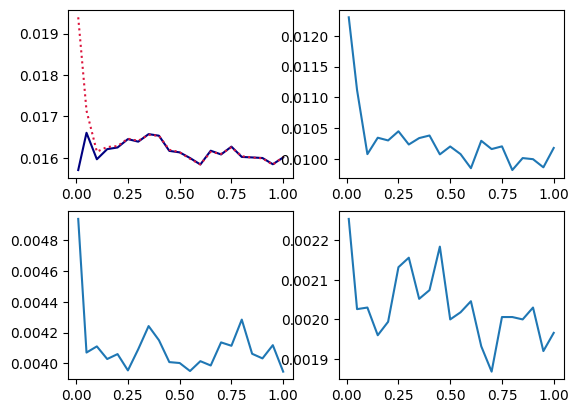

In [153]:
fig, ((axG, ax1), (ax2, ax3)) = plt.subplots(2, 2)
axG.plot(r_0s, [empirical_rhos[i][0] for i in range(len(r_0s))], color='navy')
axG.plot(r_0s, probs, color='crimson', ls=':')
ax1.plot(r_0s, [empirical_rhos[i][1] for i in range(len(r_0s))])
ax2.plot(r_0s, [empirical_rhos[i][2] for i in range(len(r_0s))])
ax3.plot(r_0s, [empirical_rhos[i][3] for i in range(len(r_0s))])
plt.show()

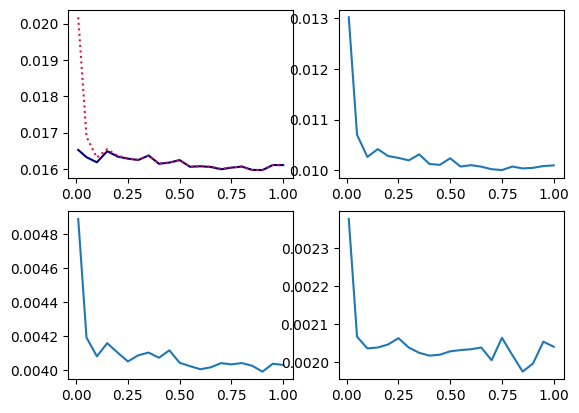

In [149]:
fig, ((axG, ax1), (ax2, ax3)) = plt.subplots(2, 2)
axG.plot(r_0s, [empirical_rhos[i][0] for i in range(len(r_0s))], color='navy')
axG.plot(r_0s, probs, color='crimson', ls=':')
ax1.plot(r_0s, [empirical_rhos[i][1] for i in range(len(r_0s))])
ax2.plot(r_0s, [empirical_rhos[i][2] for i in range(len(r_0s))])
ax3.plot(r_0s, [empirical_rhos[i][3] for i in range(len(r_0s))])
plt.show()

### Layer Overlap

As $\alpha \to \infty$, the assignment of affiliations is independent of space, and the density of layer $\ell$ tends to $\frac{1}{K^\ell}$. Independence of space implies indepence of affiliation choice across layers. Thus, the expected overlap in edges between two layers $\ell$ and $\ell'$ is $\frac{1}{K^\ell K^{\ell'}}$.

In [401]:
original_L = cfg.network.n_layers
original_K = cfg.network.n_affiliations
original_r_0 = cfg.connection.r_0
original_N = cfg.network.n_nodes

Ks = [random.randint(100,800),random.randint(100,800),random.randint(100,800)]

cfg.connection.r_0 = 100
cfg.network.n_layers = 3
cfg.network.n_affiliations = Ks
cfg.network.n_nodes = random.randint(1000,5000)

G, layers = gen(cfg, rng)

for l1, l2 in itertools.combinations(layers, 2):
    i = layers.index(l1)
    j = layers.index(l2)

    emp_prob = len(set(l1.edges).intersection(set(l2.edges))) / math.comb(cfg.network.n_nodes,2)
    est_prob = 1/(Ks[i]*Ks[j])
    print(f'The probability of an edge being in both layers {i+1} and {j+1} is {emp_prob:.6f} which is approximately {est_prob:.6f}, err={emp_prob/est_prob:.3f}.')


cfg.network.n_layers = original_L
cfg.network.n_affiliations = original_K
cfg.connection.r_0 = original_r_0
cfg.network.n_nodes = original_N

The probability of an edge being in both layers 1 and 2 is 0.000007 which is approximately 0.000007, err=0.916.
The probability of an edge being in both layers 1 and 3 is 0.000005 which is approximately 0.000005, err=1.039.
The probability of an edge being in both layers 2 and 3 is 0.000008 which is approximately 0.000007, err=1.175.


As $\alpha \to 0$ spatial dependence is high, and choice of affiliation is highly dependent across layers.

OLD

In [ ]:
plt.plot(np.linspace(0,1,51),[float(elem[0]) for elem in read_lookup_from_file("p_deltas_r025.csv")])
plt.xlabel('Distance $\\delta$')
plt.ylabel('$q_{\\delta}$')

In [340]:
deltas = np.linspace(0,1,51)
p_deltas = [float(elem[0]) for elem in read_lookup_from_file("p_deltas_r025.csv")]

OLD

In [191]:
G, layers = gen(cfg, rng)

In [192]:
edge_sets = [set(layer.edges) for layer in layers]

In [161]:
import itertools

In [218]:
ovs = [0,0,0]
n_trials = 100

for _ in range(n_trials):
    G, layers = gen(cfg, rng)
    for i, (l1, l2) in enumerate(itertools.combinations(range(cfg.network.n_layers), 2)):
        overlap = len(edge_sets[l1].intersection(edge_sets[l2]))
        ovs[i] += overlap / math.comb(cfg.network.n_nodes, 2)

ovs = [ov / n_trials for ov in ovs]

In [219]:
ovs

[3.8038038038038116e-05, 2.402402402402404e-05, 4.004004004003998e-06]

In [217]:
ovs

[3.803803803803804e-05, 2.4024024024024024e-05, 4.004004004004003e-06]

In [344]:
cfg.analysis.mc.n_trials = 1000

In [349]:
original_n_trials = cfg.analysis.mc.n_trials 
cfg.analysis.mc.n_trials = 20
weighting_lkup, weighting_coords = gen_expected_weighting_lookup(cfg)
cfg.analysis.mc.n_trials = original_n_trials

In [356]:
weighting_lkup = read_lookup_from_file("weighting_lookup_r025.csv")
weighting_lkup = [[float(elem) for elem in row] for row in weighting_lkup]
weighting_coords = coord_vals = np.linspace(0, 1, cfg.analysis.mc.omega_lookup_res)

In [370]:
original_n_trials = cfg.analysis.mc.n_trials 
cfg.analysis.mc.n_trials = 100
deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_deltas_100 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
p_deltas_250 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=250) for delta in deltas]
p_deltas_500 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=500) for delta in deltas]
cfg.analysis.mc.n_trials = original_n_trials

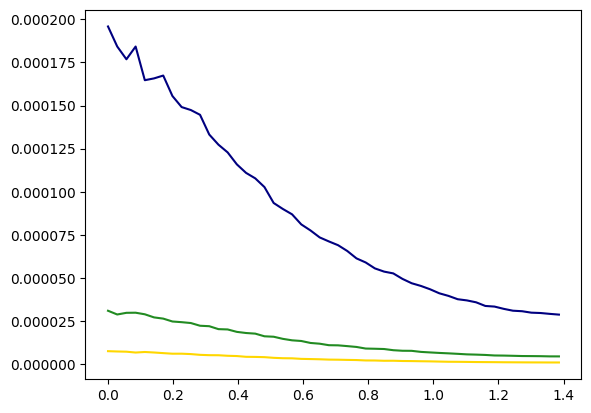

In [372]:
plt.plot(deltas, p_deltas_100, color='navy')
plt.plot(deltas, p_deltas_250, color='forestgreen')
plt.plot(deltas, p_deltas_500, color='gold')

In [373]:
original_L = cfg.network.n_layers
original_K = cfg.network.n_affiliations

cfg.network.n_layers = 3
cfg.network.n_affiliations = [100, 250, 500]
G, layers = gen(cfg, rng)

Overlap between layers with $K=100$ and $K=250$

In [375]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_250[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)

In [376]:
overlap

np.float64(1.3355038818260768e-09)

In [380]:
len(set(layers[0].edges).intersection(set(layers[1].edges)))

26

In [381]:
E = len(layers[0].edges)
print(len(set(layers[0].edges).intersection(set(layers[1].edges))) / E)
print(overlap * E)

0.005095042132079169
6.81507630895847e-06


In [382]:
overlap / nx.density(layers[0])

np.float64(1.307239249406477e-07)

In [374]:
for l in layers:
    print(nx.density(l))

0.010216216216216217
0.004032032032032032
0.00207007007007007


OLD

In [211]:
deltas = np.linspace(0,math.sqrt(2),51)[:-1]
p_deltas_100 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=100) for delta in deltas]
p_deltas_250 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=250) for delta in deltas]
p_deltas_500 = [p_delta(cfg, delta, weighting_coords, weighting_lkup, K=500) for delta in deltas]

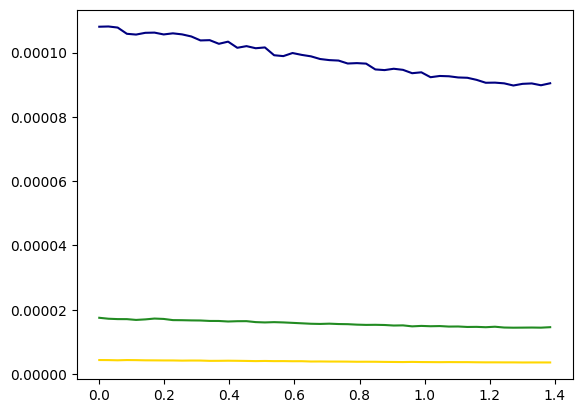

In [212]:
plt.plot(deltas, p_deltas_100, color='navy')
plt.plot(deltas, p_deltas_250, color='forestgreen')
plt.plot(deltas, p_deltas_500, color='gold')

In [213]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_250[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)
print(overlap * math.comb(cfg.network.n_nodes, 2))

0.0005732372085783392


In [214]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_100[i] * p_deltas_500[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)
print(overlap * math.comb(cfg.network.n_nodes, 2))

0.00014354666567789593


In [215]:
total = 0
for i, delta in enumerate(deltas):
    total += p_deltas_250[i] * p_deltas_500[i] * sq_line_picking_prob(cfg, delta)
overlap = total / len(deltas)
print(overlap * math.comb(cfg.network.n_nodes, 2))

2.2968131675881097e-05


In [206]:
0.00002

2e-05